Plot salvato in: C:\Users\geard\OneDrive\Download\dataset1_confronto.jpeg


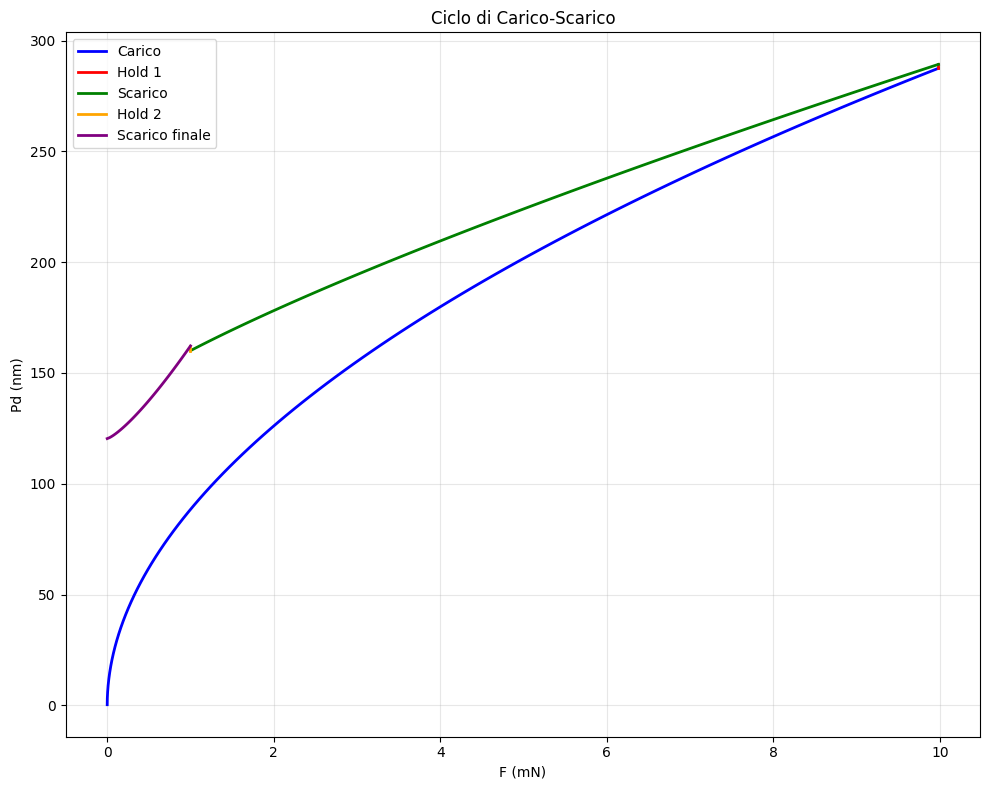

Punti chiave del ciclo:
start: h=0.300, F=0.000
end_loading: h=287.489, F=9.983
end_hold1: h=289.262, F=9.983
end_unloading: h=160.071, F=1.000
end_hold2: h=162.222, F=1.000
end_final: h=120.388, F=0.000


In [3]:
import numpy as np
import matplotlib.pyplot as plt

class LoadingCycle:
    def __init__(self, loading_params, unloading_params, final_unloading_params, 
                 c1, c2):
        """
        Inizializza il ciclo di carico-scarico
        
        Parameters:
        -----------
        loading_params : dict
            {'a': float, 'm': float, 'h0': float} - parametri per F = a*(h-h0)^m
        unloading_params : dict
            {'a': float, 'm': float, 'h0': float} - parametri per F = a*(h-h0)^m
        final_unloading_params : dict
            {'a': float, 'm': float, 'h0': float} - parametri per F = a*(h-h0)^m
        c1 : float
            Forza costante per primo hold (fine loading)
        c2 : float
            Forza costante per secondo hold (fine unloading)
        hold1_duration : float
            Incremento di h durante hold1 (default 0.1)
        hold2_duration : float
            Decremento di h durante hold2 (default 0.1)
        """
        self.loading_params = loading_params
        self.unloading_params = unloading_params
        self.final_unloading_params = final_unloading_params
        self.c1 = c1
        self.c2 = c2
        
        # Calcola i punti di transizione del percorso
        self._calculate_path_points()
    
    def _calculate_path_points(self):
        """Calcola i punti chiave del percorso h-F"""
        
        # Punto 1: Fine loading (F raggiunge c1)
        a1, m1, h0_1 = self.loading_params['a'], self.loading_params['m'], self.loading_params['h0']
        self.h1 = h0_1 + (self.c1 / a1) ** (1/m1)
        
        # Punto 2: Fine hold1 (h continua a salire)
        a2, m2, h0_2 = self.unloading_params['a'], self.unloading_params['m'], self.unloading_params['h0']
        self.h2 = h0_2 + (self.c1 / a2) ** (1/m2)
        
        # Per l'unloading, dobbiamo trovare h3 tale che quando h scende da h2 a h3,
        # F scende da c1 a c2 seguendo F = a2*(h-h0_2)^m2

        
        # Risolviamo per h3: h3 = h0_2 + (c2/a2)^(1/m2)
        self.h3 = h0_2 + (self.c2 / a2) ** (1/m2)
        
        # Punto 4: Fine hold2 (h continua a scendere)
        a3, m3, h0_3 = self.final_unloading_params['a'], self.final_unloading_params['m'], self.final_unloading_params['h0']
        self.h4 = h0_3 + (self.c2 / a3) ** (1/m3)
        
        # Punto 5: Fine final unloading (F=0)
        # 0 = a3*(h5-h0_3)^m3, quindi h5 = h0_3
        self.h5 = h0_3
        
        # Salva i punti del percorso
        self.path_points = {
            'start': (h0_1, 0),
            'end_loading': (self.h1, self.c1),
            'end_hold1': (self.h2, self.c1),
            'end_unloading': (self.h3, self.c2),
            'end_hold2': (self.h4, self.c2),
            'end_final': (self.h5, 0)
        }
    
    def generate_cycle_path(self, n_loading=100, n_hold1=20, n_unloading=100, 
                           n_hold2=20, n_final=100):
        """
        Genera il percorso completo del ciclo
        
        Parameters:
        -----------
        n_* : int
            Numero di punti per ogni fase
            
        Returns:
        --------
        h_path : array
            Valori di h lungo il percorso
        F_path : array
            Valori di F lungo il percorso
        phase_path : array
            Fase corrispondente per ogni punto
        """
        
        h_path = []
        F_path = []
        phase_path = []
        
        # 1. Loading: h da h0_1 a h1
        h0_1 = self.loading_params['h0']
        h_loading = np.linspace(h0_1, self.h1, n_loading)
        a1, m1 = self.loading_params['a'], self.loading_params['m']
        F_loading = a1 * (h_loading - h0_1) ** m1
        
        h_path.extend(h_loading)
        F_path.extend(F_loading)
        phase_path.extend(['loading'] * n_loading)
        
        # 2. Hold1: F costante c1, h varia (creep) - LINEA VERTICALE nel grafico F-h
        F_hold1 = np.full(n_hold1, self.c1)  # F costante
        h_hold1 = np.linspace(self.h1, self.h2, n_hold1)  # h varia
        
        h_path.extend(h_hold1)
        F_path.extend(F_hold1)
        phase_path.extend(['hold1'] * n_hold1)
        
        # 3. Unloading: h da h2 a h3, F da c1 a c2
        h_unloading = np.linspace(self.h2, self.h3, n_unloading)
        a2, m2, h0_2 = self.unloading_params['a'], self.unloading_params['m'], self.unloading_params['h0']
        F_unloading = a2 * (h_unloading - h0_2) ** m2
        
        h_path.extend(h_unloading)
        F_path.extend(F_unloading)
        phase_path.extend(['unloading'] * n_unloading)
        
        # 4. Hold2: F costante c2, h varia (creep) - LINEA VERTICALE nel grafico F-h
        F_hold2 = np.full(n_hold2, self.c2)  # F costante  
        h_hold2 = np.linspace(self.h3, self.h4, n_hold2)  # h varia
        
        h_path.extend(h_hold2)
        F_path.extend(F_hold2)
        phase_path.extend(['hold2'] * n_hold2)
        
        # 5. Final unloading: h da h4 a h5, F da c2 a 0
        h_final = np.linspace(self.h4, self.h5, n_final)
        a3, m3, h0_3 = self.final_unloading_params['a'], self.final_unloading_params['m'], self.final_unloading_params['h0']
        F_final = np.maximum(0, a3 * (h_final - h0_3) ** m3)
        
        h_path.extend(h_final)
        F_path.extend(F_final)
        phase_path.extend(['final_unloading'] * n_final)
        
        return np.array(h_path), np.array(F_path), np.array(phase_path)
    
    def evaluate_at_h(self, h_query):
        """
        Valuta F per un dato h, determinando la fase più appropriata
        
        Parameters:
        -----------
        h_query : float or array-like
            Altezza(e) a cui valutare
            
        Returns:
        --------
        F : float or array-like
            Forza corrispondente
        phase : str or array-like
            Fase più probabile
        """
        is_scalar = np.isscalar(h_query)
        h_query = np.atleast_1d(h_query)
        F = np.zeros_like(h_query, dtype=float)
        phases = np.full_like(h_query, '', dtype='U20')
        
        for i, h in enumerate(h_query):
            # Determina la fase più probabile basandosi sui range di h
            h0_1 = self.loading_params['h0']
            
            if h <= h0_1:
                F[i] = 0
                phases[i] = 'pre_loading'
            elif h0_1 < h <= self.h1:
                # Loading
                a, m, h0 = self.loading_params['a'], self.loading_params['m'], self.loading_params['h0']
                F[i] = a * (h - h0) ** m
                phases[i] = 'loading'
            elif self.h1 < h <= self.h2:
                # Hold1 o inizio unloading
                F[i] = self.c1
                phases[i] = 'hold1_or_unloading'
            elif self.h3 <= h <= self.h2:
                # Unloading (range dove h può stare scendendo)
                a, m, h0 = self.unloading_params['a'], self.unloading_params['m'], self.unloading_params['h0']
                F[i] = a * (h - h0) ** m
                phases[i] = 'unloading'
            elif self.h4 <= h <= self.h3:
                # Hold2 o final unloading
                F[i] = self.c2
                phases[i] = 'hold2_or_final'
            elif h <= self.h4:
                # Final unloading
                a, m, h0 = self.final_unloading_params['a'], self.final_unloading_params['m'], self.final_unloading_params['h0']
                F[i] = max(0, a * (h - h0) ** m)
                phases[i] = 'final_unloading'
            else:
                # Fuori range
                F[i] = 0
                phases[i] = 'out_of_range'
        
        if is_scalar:
            return float(F[0]), phases[0]
        return F, phases
    
    def plot_cycle(self, savepath, figsize=(10, 8)):
        """
        Plotta il ciclo F-h in modo semplice e pulito
        """
        # Genera il percorso del ciclo
        h_path, F_path, phase_path = self.generate_cycle_path()
        
        fig, ax = plt.subplots(1, 1, figsize=figsize)
        
        # Colori semplici per le fasi
        phase_colors = {
            'loading': 'blue',
            'hold1': 'red', 
            'unloading': 'green',
            'hold2': 'orange',
            'final_unloading': 'purple'
        }
        
        phase_labels = {
            'loading': 'Carico',
            'hold1': 'Hold 1', 
            'unloading': 'Scarico',
            'hold2': 'Hold 2',
            'final_unloading': 'Scarico finale'
        }
        
        # Plot delle fasi
        current_phase = phase_path[0]
        start_idx = 0
        
        for i in range(1, len(phase_path)):
            if phase_path[i] != current_phase:
                color = phase_colors.get(current_phase, 'black')
                label = phase_labels.get(current_phase, current_phase)
                ax.plot(F_path[start_idx:i+1], h_path[start_idx:i+1], 
                       color=color, linewidth=2, label=label)
                start_idx = i
                current_phase = phase_path[i]
        
        # Ultima fase
        color = phase_colors.get(current_phase, 'black')
        label = phase_labels.get(current_phase, current_phase)
        ax.plot(F_path[start_idx:], h_path[start_idx:], 
               color=color, linewidth=2, label=label)
        
        # Assi e titolo
        ax.set_xlabel('F (mN)')
        ax.set_ylabel('Pd (nm)')
        ax.set_title('Ciclo di Carico-Scarico')
        
        # Legenda semplice
        ax.legend()
        
        # Griglia leggera
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()

        # Aggiunta per salvare il plot
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight') # Salva con 300 dpi e rimuove spazi bianchi
            print(f"Plot salvato in: {save_path}")
        
        plt.show()
        
        # Stampa informazioni sui punti chiave
        print("Punti chiave del ciclo:")
        for name, (h, F) in self.path_points.items():
            print(f"{name}: h={h:.3f}, F={F:.3f}")
        
        return h_path, F_path, phase_path

# Esempio di utilizzo
if __name__ == "__main__":
    # Parametri di esempio con h0 diversi per ogni fase
    loading_params = {'a': 1.630870e-04, 'm': 1.947328, 'h0': 0.300202}
    unloading_params = {'a': 1.853780e-02, 'm': 1.249291, 'h0': 135.724342}
    final_unloading_params = {'a': 5.486578e-02, 'm': 0.777551, 'h0': 120.388321}
    
    c1 = 9.983396  # Forza hold 1
    c2 = 1.000272  # Forza hold 2
    
    # Crea il ciclo
    cycle = LoadingCycle(loading_params, unloading_params, final_unloading_params, 
                        c1, c2)

    save_path=r"C:\Users\geard\OneDrive\Download\dataset1_confronto.jpeg"
    # Plot del ciclo migliorato (solo F-h)
    h_path, F_path, phase_path = cycle.plot_cycle(save_path)